In [1]:



# You’re optimising an eight-dimensional black-box function, where each of the eight input parameters affects the output, 
# but the internal mechanics are unknown. 

# Your objective is to find the parameter combination that maximises the function’s output, 
# such as performance, efficiency or validation accuracy. Because the function is high-dimensional 
# and likely complex, global optimisation is hard, so identifying strong local maxima is often a practical strategy.

# For example, imagine you’re tuning an ML model with eight hyperparameters: 
# learning rate, batch size, number of layers, dropout rate, regularisation strength, 
# activation function (numerically encoded), optimiser type (encoded) and initial weight range. 
# Each input set returns a single validation accuracy score between 0 and 1. Your goal is to maximise this score.



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X = np.load('initial_inputs.npy')
y = np.load('initial_outputs.npy')

week1_X = [0.037897, 0.017931, 0.035032, 0.225387, 0.022555, 0.624348, 0.009878, 0.901238]
week1_y = 9.5430642790311

# [0.037897, 0.017931, 0.035032, 0.225387, 0.022555, 0.624348, 0.009878, 0.901238]
# 9.5430642790311

X = np.vstack([X, week1_X])
y = np.append(y, week1_y)

# print('-- inputs X ---')
# print(X)
# print("X shape=",X.shape)

# print('-- outputs y ---')
# print(y)
print("y shape=",y.shape)

# Set random seed for reproducibility
np.random.seed(42)

y shape= (41,)


In [3]:
df = pd.DataFrame(X, columns=["x1","x2","x3","x4","x5","x6","x7","x8"])
df['y'] = y
df = df.sort_values(by='y', ascending=False)
df.head(2)

# week 1 query is in 2nd place 
# 40	0.037897	0.017931	0.035032	0.225387	0.022555	0.624348	0.009878	0.901238	9.543064


,x1,x2,x3,x4,x5,x6,x7,x8,y
14,0.056447,0.065956,0.022929,0.038786,0.403935,0.801055,0.488307,0.893085,9.598482
40,0.037897,0.017931,0.035032,0.225387,0.022555,0.624348,0.009878,0.901238,9.543064


In [4]:
df.tail(2)

,x1,x2,x3,x4,x5,x6,x7,x8,y
21,0.898887,0.523642,0.876783,0.218696,0.900261,0.282766,0.911078,0.472398,5.841067
9,0.984933,0.699506,0.998885,0.180148,0.580143,0.231087,0.490827,0.313683,5.592193


In [17]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from scipy.stats import norm
import warnings
from sklearn.exceptions import ConvergenceWarning

# Put this at the very top of your script
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# Simplify to just Matern
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=[0.5]*8, 
                                      length_scale_bounds=(1e-3, 1e5), 
                                      nu=2.5) 
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.2, normalize_y=True, n_restarts_optimizer=10)


# week 2
# kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=[0.5]*8, 
#                                       length_scale_bounds=(1e-3, 1e5), 
#                                       nu=2.5) 
# gp = GaussianProcessRegressor(kernel=kernel, alpha=0.1, normalize_y=True, n_restarts_optimizer=10)

gp.fit(X, y)


print(f"Optimized Kernel: {gp.kernel_}")
print(f"Training R^2 Score: {gp.score(X, y)}")
print(f"Total variance accounted for as noise: {gp.alpha}")

# week1
# Optimized Kernel: 3.32**2 * Matern(length_scale=[2.63, 7.59, 1.88, 14, 2.58e+04, 1e+05, 3.72, 1e+05], nu=2.5)
# Training R^2 Score: 0.9508966963836125
# Total variance accounted for as noise: 0.2

# week2
# Optimized Kernel: 3.26**2 * Matern(length_scale=[2.48, 6.42, 1.84, 10.4, 22, 5.84e+04, 3.15, 6.91e+04], nu=2.5)
# Training R^2 Score: 0.9748074760184751
# Total variance accounted for as noise: 0.1

# x6,x8 - flat  - large scale
# x1,x3,x7 - sensitive
# X2,x4,x5 - moderate
#    x1   x2    x3    x4   x5       x6     x7    x8
# [2.48, 6.42, 1.84, 10.4, 22, 5.84e+04, 3.15, 6.91e+04]

# Keeping week1 GP setting later we cand reduce the noise = 0.1, For now lets keep exploration

# For week2 continue as it is giving improvement
# expected_improvement with xi: 0.01
# Current Best y: 9.598482002566342
# Suggested next: [0.00315918 0.0974036  0.05199988 0.05918353 0.30666452 0.71104932 0.02446955 0.63619625]
# Sigma: [0.30535637]

Optimized Kernel: 2.76**2 * Matern(length_scale=[2.29, 6.89, 1.65, 13.8, 9.3e+03, 1e+05, 3.3, 1e+05], nu=2.5)
Training R^2 Score: 0.9511165826462231
Total variance accounted for as noise: 0.2


In [6]:
def upper_confidence_bound(mu, sigma, kappa=2.0):
    """
    kappa = 1.96  -> 95% confidence (Balanced)
    kappa = 2.576 -> 99% confidence (More Exploration)
    """
    return mu + kappa * sigma
    
def expected_improvement(mu, sigma, y_best, xi=0.01):
    with np.errstate(divide='warn'):
        improvement = mu - y_best - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# Predict
#  increase sample to 100,000
X_grid = np.random.uniform(0, 1, size=(100000, 8)) 
mu, sigma = gp.predict(X_grid, return_std=True)

sigma = sigma.reshape(-1, 1)
mu = mu.reshape(-1, 1)
y_best = y.max()


In [7]:
xi=0.01
ei_values = expected_improvement(mu, sigma, y_best, xi)

# Get the next best point
ei_next_idx = np.argmax(ei_values)
ei_next_query = X_grid[ei_next_idx]

print(f"expected_improvement with xi: {xi}")
print(f"Current Best y: {y.max()}")
print(f"Suggested next: {ei_next_query}")
print(f"Sigma: {sigma[ei_next_idx]}")

# best combination so far 
#     x1	  x2	     x3	          x4	      x5	      x6	     x7	          x8	     y
# 0.056447	0.065956	0.022929	0.038786	0.403935	0.801055	0.488307	0.893085	9.598482
# Suggested next: 
#     x1	  x2	     x3	          x4	      x5	      x6	     x7	          x8	                  y
# [0.03789746 0.01793121 0.03503221 0.22538739 0.02255555 0.62434896 0.00987856 0.90123825]

expected_improvement with xi: 0.01
Current Best y: 9.598482002566342
Suggested next: [0.02660603 0.16146775 0.10473531 0.01222607 0.53431035 0.3876256
 0.00921142 0.82857017]
Sigma: [0.29042604]


In [8]:
# kappa = 2.0 is a great starting point for week 1
kappa=2.0
ucb_values = upper_confidence_bound(mu, sigma, kappa)


ucb_next_idx = np.argmax(ucb_values)
ucb_next_query = X_grid[ucb_next_idx]

print(f"UCB with kappa: {kappa}")
print(f"Current Best y: {y.max()}")
print(f"Suggested next: {ucb_next_query}")
print(f"Sigma: {sigma[ucb_next_idx]}")

# best combination so far 
#     x1	  x2	     x3	          x4	      x5	      x6	     x7	          x8	     y
# 0.056447	0.065956	0.022929	0.038786	0.403935	0.801055	0.488307	0.893085	9.598482
# Suggested next: 
#     x1	  x2	     x3	          x4	      x5	      x6	     x7	          x8	                  y
# [0.03789746 0.01793121 0.03503221 0.22538739 0.02255555 0.62434896 0.00987856 0.90123825]

UCB with kappa: 2.0
Current Best y: 9.598482002566342
Suggested next: [0.02660603 0.16146775 0.10473531 0.01222607 0.53431035 0.3876256
 0.00921142 0.82857017]
Sigma: [0.29042604]


In [9]:
# next query check
# If std is non-trivial → still exploring
# If std ≈ sqrt(alpha) → pure exploitation
# Exploration vs Exploitation check on the next query point

# | Metric                  | Interpretation             |
# | ----------------------- | -------------------------- |
# | mu_real ≪ y_best        | Not exploitation           |
# | std_real small          | Already well-known, ignore |
# | std_real moderate/large | Worth exploring            |


mu_norm, std_norm = gp.predict(ei_next_query.reshape(1, -1), return_std=True)

# Training  mean and std
y_mean_train = gp._y_train_mean
y_std_train = gp._y_train_std

# calculate real value as the normalise=True in the GPR
mu_real  = mu_norm * y_std_train + y_mean_train
std_real = std_norm * y_std_train

print("Training y_mean:", gp._y_train_mean)
print("Training y_std:", gp._y_train_std)
print(f"NextQuery(normal space) mu:{mu_norm}, std:{std_norm}")
print(f"NextQuery mu_real:{mu_real}, std_real:{std_real}")

# μreal ≥ ybest − δ  (Exploitation)
# else
# μreal < ybest−δ and σ real≥ threshold (Exploration)
# else ingore it pointless i.e. the query is already well known in the current space.

def classify_query(mu_real, std_real, y_best):
    delta = 0.05 * y_best        # exploitation tolerance
    sigma_thresh = 0.05 * y_best # exploration threshold
    
    if mu_real >= y_best - delta:
        return "Exploitation"
    elif std_real >= sigma_thresh:
        return "Exploration"
    else:
        return "Pointless"

classify_query(mu_real, std_real, y_best)

Training y_mean: 7.857415673307176
Training y_std: 0.9725186465660848
NextQuery(normal space) mu:[9.75647787], std:[0.29042604]
NextQuery mu_real:[17.34577233], std_real:[0.28244474]


'Exploitation'

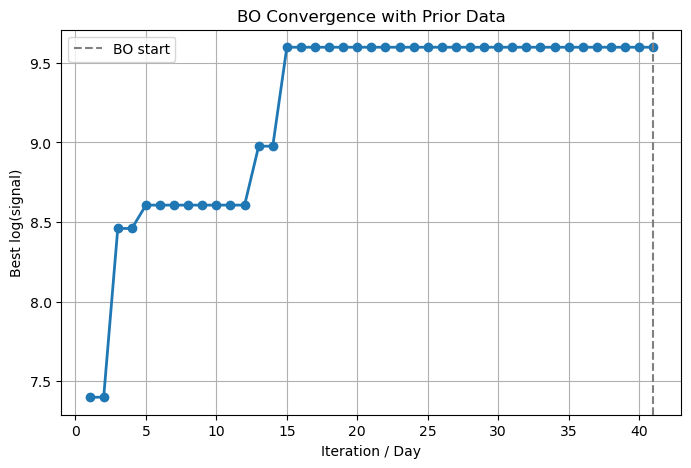

In [18]:
# Convergence Plot over the y-results

y_observed = y

iterations = np.arange(1, len(y_observed) + 1)
bo_best_y = np.maximum.accumulate(y_observed)

bo_start_idx = 40  # zero-based index of first BO point

plt.figure(figsize=(8,5))
plt.plot(iterations, bo_best_y, marker='o', linewidth=2)

# Vertical line separating phases
plt.axvline(x=bo_start_idx + 1, color='gray', linestyle='--', label='BO start')

plt.xlabel("Iteration / Day")
plt.ylabel("Best log(signal)")
plt.title("BO Convergence with Prior Data")
plt.grid(True)
plt.legend()

plt.show()

In [ ]:
# Observation
# verdict: more exploitative
# expected_improvement with xi: 0.01
# Current Best y: 9.598482002566342
# Suggested next: [0.02660603 0.16146775 0.10473531 0.01222607 0.53431035 0.3876256 0.00921142 0.82857017]
# Sigma: [0.29042604]